In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')



df = pd.read_excel('/content/drive/MyDrive/student_math_clean.xlsx')

In [95]:
df.shape

(395, 34)

In [96]:
df.head()

,student_id,school,sex,age,address_type,family_size,parent_status,mother_education,father_education,mother_job,...,family_relationship,free_time,social,weekday_alcohol,weekend_alcohol,health,absences,grade_1,grade_2,final_grade
0,1,GP,F,18,Urban,Greater than 3,Apart,higher education,higher education,at_home,...,4,3,4,1,1,3,6,5,6,6
1,2,GP,F,17,Urban,Greater than 3,Living together,primary education (4th grade),primary education (4th grade),at_home,...,5,3,3,1,1,3,4,5,5,6
2,3,GP,F,15,Urban,Less than or equal to 3,Living together,primary education (4th grade),primary education (4th grade),at_home,...,4,3,2,2,3,3,10,7,8,10
3,4,GP,F,15,Urban,Greater than 3,Living together,higher education,5th to 9th grade,health,...,3,2,2,1,1,5,2,15,14,15
4,5,GP,F,16,Urban,Greater than 3,Living together,secondary education,secondary education,other,...,4,3,2,1,2,5,4,6,10,10


In [97]:
df.columns

Index(['student_id', 'school', 'sex', 'age', 'address_type', 'family_size',
       'parent_status', 'mother_education', 'father_education', 'mother_job',
       'father_job', 'school_choice_reason', 'guardian', 'travel_time',
       'study_time', 'class_failures', 'school_support', 'family_support',
       'extra_paid_classes', 'activities', 'nursery_school', 'higher_ed',
       'internet_access', 'romantic_relationship', 'family_relationship',
       'free_time', 'social', 'weekday_alcohol', 'weekend_alcohol', 'health',
       'absences', 'grade_1', 'grade_2', 'final_grade'],
      dtype='object')

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             395 non-null    int64 
 1   school                 395 non-null    object
 2   sex                    395 non-null    object
 3   age                    395 non-null    int64 
 4   address_type           395 non-null    object
 5   family_size            395 non-null    object
 6   parent_status          395 non-null    object
 7   mother_education       395 non-null    object
 8   father_education       395 non-null    object
 9   mother_job             395 non-null    object
 10  father_job             395 non-null    object
 11  school_choice_reason   395 non-null    object
 12  guardian               395 non-null    object
 13  travel_time            395 non-null    object
 14  study_time             395 non-null    object
 15  class_failures         

In [99]:
df.isnull().sum()



,0
student_id,0
school,0
sex,0
age,0
address_type,0
family_size,0
parent_status,0
mother_education,0
father_education,0
mother_job,0


In [100]:
categorical = df.select_dtypes(include=['object'])
numeric = df.select_dtypes(include=['int64', 'float64'])

categorical.columns, numeric.columns


(Index(['school', 'sex', 'address_type', 'family_size', 'parent_status',
        'mother_education', 'father_education', 'mother_job', 'father_job',
        'school_choice_reason', 'guardian', 'travel_time', 'study_time',
        'school_support', 'family_support', 'extra_paid_classes', 'activities',
        'nursery_school', 'higher_ed', 'internet_access',
        'romantic_relationship'],
       dtype='object'),
 Index(['student_id', 'age', 'class_failures', 'family_relationship',
        'free_time', 'social', 'weekday_alcohol', 'weekend_alcohol', 'health',
        'absences', 'grade_1', 'grade_2', 'final_grade'],
       dtype='object'))

In [101]:
for col in categorical.columns:
    print(f"{col}:\n{df[col].value_counts()}\n")


school:
school
GP    349
MS     46
Name: count, dtype: int64

sex:
sex
F    208
M    187
Name: count, dtype: int64

address_type:
address_type
Urban    307
Rural     88
Name: count, dtype: int64

family_size:
family_size
Greater than 3             281
Less than or equal to 3    114
Name: count, dtype: int64

parent_status:
parent_status
Living together    354
Apart               41
Name: count, dtype: int64

mother_education:
mother_education
higher education                 131
5th to 9th grade                 103
secondary education               99
primary education (4th grade)     59
none                               3
Name: count, dtype: int64

father_education:
father_education
5th to 9th grade                 115
secondary education              100
higher education                  96
primary education (4th grade)     82
none                               2
Name: count, dtype: int64

mother_job:
mother_job
other       141
services    103
at_home      59
teacher      58
health 

In [102]:
numeric_cols = [ 'age', 'class_failures', 'family_relationship',
                 'free_time', 'social', 'weekday_alcohol', 'weekend_alcohol',
                 'health', 'absences', 'grade_1', 'grade_2']

bin_no_yesno  = ['school', 'sex', 'address_type', 'family_size','parent_status']

bin_yesno =  ['school_support', 'family_support', 'extra_paid_classes', 'activities','nursery_school', 'higher_ed',  'internet_access', 'romantic_relationship']

cat_no_binary = [ 'mother_education', 'father_education', 'mother_job', 'father_job', 'school_choice_reason', 'guardian', 'travel_time', 'study_time']


In [ ]:
numeric_df = df[numeric_cols]
no_binary_df = pd.get_dummies(df[cat_no_binary], drop_first=True, dtype='float')
binary_map = {'yes': 1, 'no': 0}
yesno_df = df[bin_yesno].replace(binary_map)

In [104]:
df['school'] = df['school'].map({'GP': 1, 'MS': 0})
df['sex']=df['sex'].map({'F': 1, 'M':0 })
df['address_type']=df['address_type'].map({'Urban':0 , 'Rural':1})
df['family_size']=df['family_size'].map({'Less than or equal to 3':0 , 'Greater than 3':1})
df['parent_status']=df['parent_status'].map({'Apart':0 , 'Living together':1})

binary_column_df=df[['school','sex','address_type', 'family_size','parent_status']]

In [105]:
X = pd.concat([numeric_df,  no_binary_df,yesno_df,binary_column_df], axis=1)

y=df['final_grade']

In [106]:
df

,student_id,school,sex,age,address_type,family_size,parent_status,mother_education,father_education,mother_job,...,family_relationship,free_time,social,weekday_alcohol,weekend_alcohol,health,absences,grade_1,grade_2,final_grade
0,1,1,1,18,0,1,0,higher education,higher education,at_home,...,4,3,4,1,1,3,6,5,6,6
1,2,1,1,17,0,1,1,primary education (4th grade),primary education (4th grade),at_home,...,5,3,3,1,1,3,4,5,5,6
2,3,1,1,15,0,0,1,primary education (4th grade),primary education (4th grade),at_home,...,4,3,2,2,3,3,10,7,8,10
3,4,1,1,15,0,1,1,higher education,5th to 9th grade,health,...,3,2,2,1,1,5,2,15,14,15
4,5,1,1,16,0,1,1,secondary education,secondary education,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,391,0,0,20,0,0,0,5th to 9th grade,5th to 9th grade,services,...,5,5,4,4,5,4,11,9,9,9
391,392,0,0,17,0,0,1,secondary education,primary education (4th grade),services,...,2,4,5,3,4,2,3,14,16,16
392,393,0,0,21,1,1,1,primary education (4th grade),primary education (4th grade),other,...,5,5,3,3,3,3,3,10,8,7
393,394,0,0,18,1,0,1,secondary education,5th to 9th grade,services,...,4,4,1,3,4,5,0,11,12,10


In [107]:
X_train , X_test, y_train, y_test=train_test_split(X,y,test_size=0.2)

In [108]:
model=LinearRegression()
model.fit(X_train,y_train)
prediction = model.predict(X_test)

In [109]:
mae=mean_absolute_error(y_test,prediction)
r2=r2_score(y_test,prediction)
mse=mean_squared_error(y_test,prediction)

print(f"Mean absolute error = {mae}")
print(f"R² score = {r2}")

print(f"Mean squared error = {mse}")
rmse = mse ** 0.5
print(f"Root mean squared error = {rmse}")

Mean absolute error = 1.4002199850008616
R² score = 0.7644114316300776
Mean squared error = 4.591806542806297
Root mean squared error = 2.142850098071794


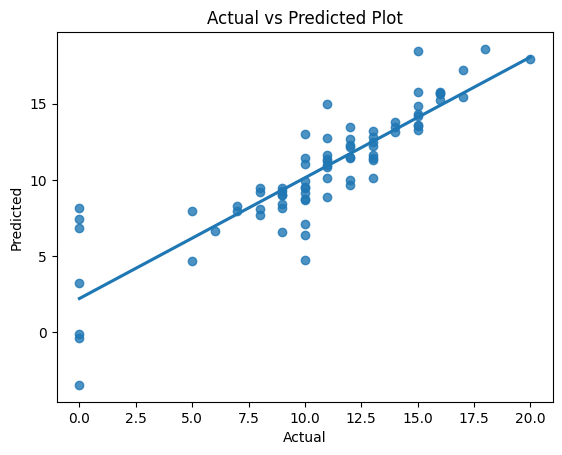

In [110]:
plot_df = pd.DataFrame({'Actual': y_test,'Predicted': prediction})

sns.regplot(data=plot_df,x='Actual',y='Predicted',ci=None)
plt.title('Actual vs Predicted Plot')
plt.show()

Text(0.5, 1.0, 'Residuals vs. Fitted values plot')

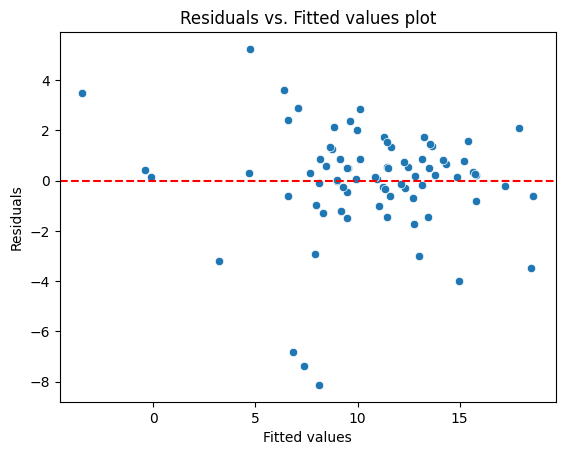

In [111]:
errors = y_test - prediction
sns.scatterplot(x=prediction, y=errors)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted values plot")
#also check if this is correct.


Text(0, 0.5, 'Actual Quantiles (Residuals)')

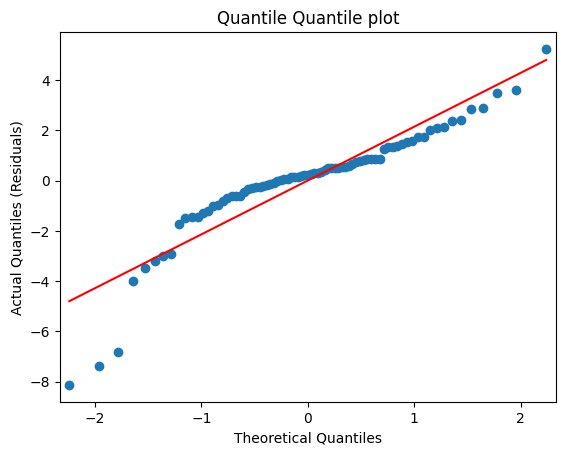

In [112]:
sm.qqplot(errors, line='s')
plt.title("Quantile Quantile plot")
plt.ylabel("Actual Quantiles (Residuals)")
#check  if this is correct,I am 99% sure it is.But still check it.-Harikesh


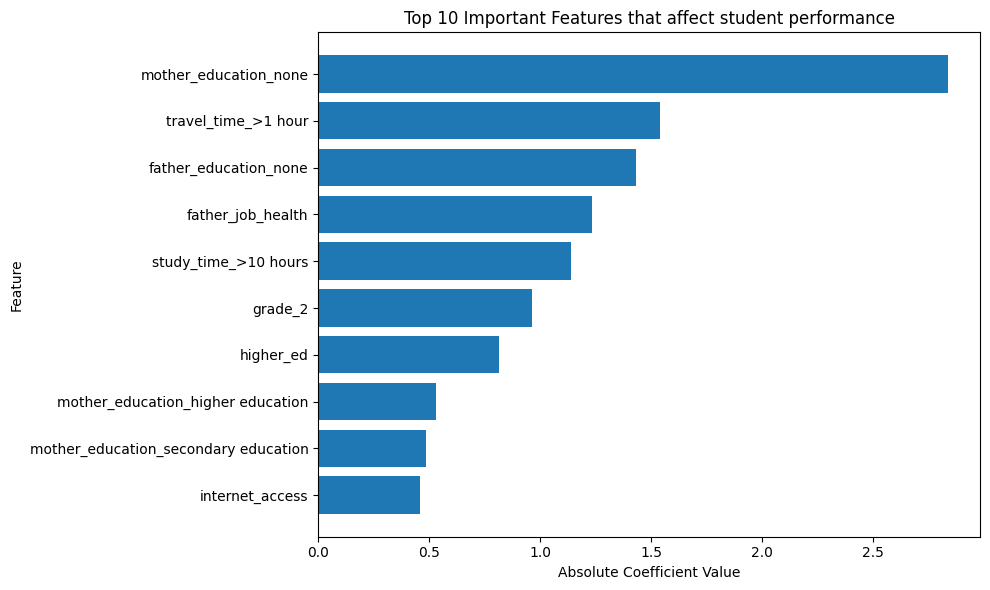

In [113]:
importance=pd.DataFrame({
    "feature": X.columns,
    "coefficient":model.coef_
})
importance["importance"]=importance["coefficient"].abs()
importance = importance.sort_values(
    by="importance",
    ascending=False
)
importance

top_n =10

top_features = importance.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Important Features that affect student performance")
plt.tight_layout()
plt.show()
